<a href="https://colab.research.google.com/github/cavalcantiju/visaocomp-1.2-ifsemif/blob/main/semana1_ifsemif.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

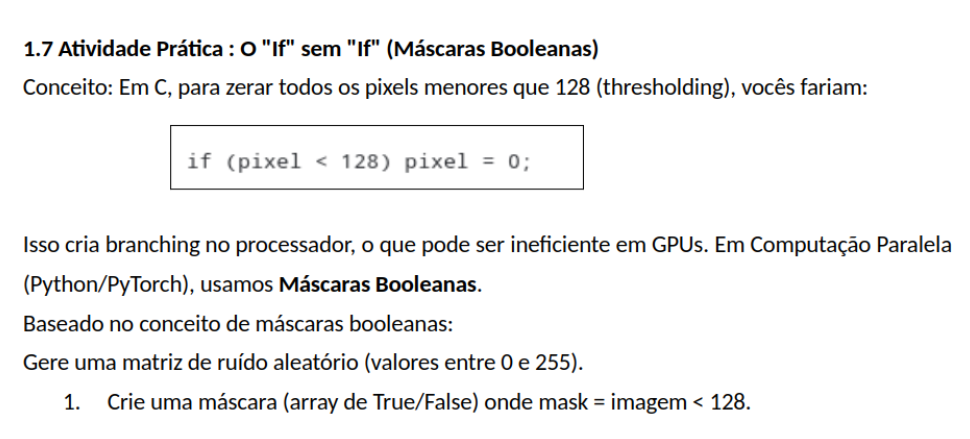

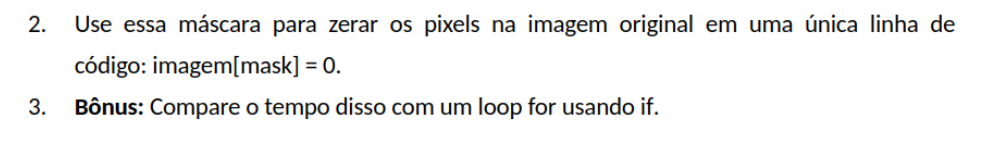

In [2]:
import numpy as np
import time

# Gerar matriz de ruído aleatório 1000x1000 (para o tempo ser perceptível)
tamanho = 1000
imagem = np.random.randint(0, 256, (tamanho, tamanho), dtype=np.int32)
imagem_loop = imagem.copy()

# --- MÉTODO 1: MÁSCARA BOOLEANA (O jeito certo) ---
start_mask = time.time()
mask = imagem < 128
imagem[mask] = 0
end_mask = time.time()

# --- MÉTODO 2: LOOP FOR + IF (O jeito lento) ---
start_loop = time.time()
for i in range(tamanho):
    for j in range(tamanho):
        if imagem_loop[i, j] < 128:
            imagem_loop[i, j] = 0
end_loop = time.time()

print(f"Tempo com Máscara: {end_mask - start_mask:.6f} segundos")
print(f"Tempo com Loop: {end_loop - start_loop:.6f} segundos")
print(f"O NumPy foi {(end_loop - start_loop) / (end_mask - start_mask):.1f}x mais rápido!")

Tempo com Máscara: 0.008723 segundos
Tempo com Loop: 0.396594 segundos
O NumPy foi 45.5x mais rápido!


A gente acabou de fazer um "If" gigante sem usar a palavra if uma única vez no processamento da imagem.

 ### Como isso funciona na prática?

A Máscara: Quando eu faço mask = imagem < 128, o NumPy cria uma matriz espelho cheia de True e False. Ele testa todos os pixels de uma vez só, em paralelo.

Aplicação Direta: Quando eu faço imagem[mask] = 0, eu estou dizendo: "Aplica o valor 0 apenas onde a máscara for True". É como colocar um molde de papel em cima de uma parede e passar spray: a tinta só pega onde tem o furo.

Por que é mais rápido? * No Loop com If, o processador tem que parar a cada pixel, perguntar "é menor que 128?", decidir o que fazer e só então ir para o próximo. Isso trava o fluxo (o tal do branching).